In [23]:
from langgraph.graph import StateGraph,START,END
from langchain_ollama import ChatOllama
from typing import TypedDict,Literal
from pydantic import BaseModel,Field

In [24]:
class Sentiment(BaseModel):

    sentiment:Literal['Postive','Negative'] =Field(description = "Sentiment of the Review")

class Diagnosis(BaseModel):

    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [25]:
llm = ChatOllama(model="llama3.2:3b", temperature=0.1,format="json")
structured_model = llm.with_structured_output(Sentiment) 
structured_model2 = llm.with_structured_output(Diagnosis) 

In [26]:
class ReviewState(TypedDict):

    review:str
    sentiment:Literal['Positive','Negative']
    diagnosis:dict
    response:str

In [41]:
def Find_Sentiment(state: ReviewState):

    prompt = f"For the Following Review Find out the Sentiment \n {state['review']}"
    sentiment = structured_model.invoke(prompt).sentiment

    return {"sentiment": sentiment}


def Check_Sentiment(
    state: ReviewState,
) -> Literal["Positive_Response", "Run_Diagnosis"]:

    if state["sentiment"] == "Positive":
        return "Positive_Response"
    else:
        return "Run_Diagnosis"


def Positive_Response(state: ReviewState):

    prompt = f"""
                Write a warm thank-you message in response to this Review:\n\n {state['review']}\n
                Also Kindly ask the user to leave a feedback on our website
            """
    response = llm.invoke(prompt).content

    return {"response":response}

def Run_Diagnosis(state:ReviewState):
    
    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
                "Return issue_type, tone, and urgency.
            """
    
    response = structured_model2.invoke(prompt)
    #json to dict
    return {'diagnosis':response.model_dump()}

def Negative_Response(state:ReviewState):
    
    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
            The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
            Write an empathetic, helpful resolution message.
            """
    response = llm.invoke(prompt).content

    return {'response':response}

In [42]:
graph = StateGraph(ReviewState)

graph.add_node("Find_Sentiment",Find_Sentiment)
graph.add_node("Positive_Response",Positive_Response)
graph.add_node("Run_Diagnosis",Run_Diagnosis)
graph.add_node("Negative_Response",Negative_Response)

graph.add_edge(START,"Find_Sentiment")
graph.add_conditional_edges("Find_Sentiment",Check_Sentiment)
graph.add_edge('Positive_Response',END)
graph.add_edge('Run_Diagnosis','Negative_Response')
graph.add_edge('Negative_Response',END)

workflow = graph.compile()

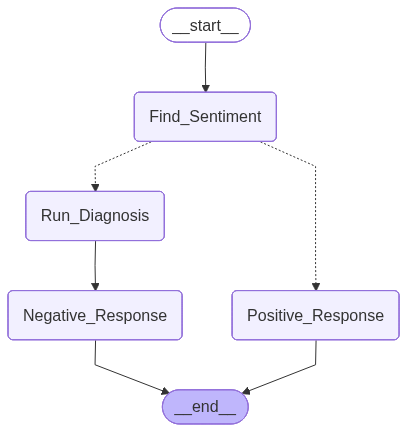

In [38]:
workflow

In [ ]:
intial_state = {
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}
workflow.invoke(intial_state)

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'Negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'},
 'response': '{ "message": "Dear [User\'s Name],\\n\\nI apologize for the inconvenience you\'ve experienced with your {bug/issue}. I can imagine how frustrating it must be to encounter this problem, especially when it affects your work or daily activities.\\n\\nOur team is committed to resolving this issue as soon as possible. We\'re working diligently to identify and fix the root cause of the problem. In the meantime, I\'d like to offer some temporary solutions to help you get back on track:\\n\\n* {Provide a list of temporary fixes or workarounds}\\n\\nPlease know that we value your patience and understanding during this time. We\'ll keep yo